# Loan Risk Classification — Grade A–G

**Structure:**
- `config.py` — paths, seed, device
- `data_processing.py` — feature engineering, ML & DL preprocessors
- `models.py` — FFNN, TabNet, TabTransformer, training loop, evaluation
- `ml_pipeline.py` — RF, KNN, SVM grid search wrappers

This notebook is the **control panel**: import modules, set hyperparameters,
launch training, evaluate.

## 0. Setup & Imports

In [1]:
import sys
import os

# Add src/ to path so we can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from config import SEED, DEVICE, MODEL_DIR, TRAIN_CSV, fix_random
from data_processing import (
    load_data,
    feature_engineer,
    build_ml_preprocessor,
    prepare_ml_data,
    prepare_dl_data,
)
from ml_pipeline import (
    train_random_forest,
    train_knn,
    train_svm,
    save_model,
    print_grid_results,
    plot_rf_feature_importances,
)
from models import (
    LoanDataset,
    TabularDataset,
    LoanClassifierFFNN,
    build_tabnet_classifier,
    train_tabnet,
    build_tab_transformer,
    build_ft_transformer,
    train_model,
    evaluate_model,
    plot_losses,
    plot_confusion_matrix,
    plot_feature_importances,
    get_class_weights,
    get_class_weights_dict,
    create_loaders,
)

fix_random(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Data Loading & Exploration

In [2]:
df = load_data(TRAIN_CSV)
df.head()

Loaded 148301 rows  (dropped 0 duplicates)


,loan_contract_approved_amount,loan_portfolio_total_funded,investor_side_funded_amount,loan_contract_term_months,loan_contract_interest_rate,loan_payment_installments_count,borrower_profile_employment_length,borrower_housing_ownership_status,borrower_income_annual,borrower_income_verification_status,...,hardship_last_payment_amount_total,disbursement_method_type,debt_settlement_flag_indicator,debt_settlement_flag_date,settlement_status_label,settlement_date,settlement_amount_total,settlement_percentage,settlement_term_months,grade
0,12000.0,11819.212488,12000.000000,36 months,12.806304,395.66,10+ years,rent,40000.0,source verified,...,NaN,cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
1,10000.0,10683.410001,10023.226279,36 months,7.890000,312.86,2 years,rent,NaN,not verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,A
2,7000.0,7000.000000,5989.447426,36 months,18.558177,253.04,8 years,mortgage,120000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,D
3,35000.0,35000.000000,35000.000000,60 months,22.950000,985.67,NaN,mortgage,99588.0,verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,F
4,2400.0,2437.596602,2400.000000,36 months,13.990000,82.02,2 years,rent,37000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148301 entries, 0 to 148300
Columns: 145 entries, loan_contract_approved_amount to grade
dtypes: float64(112), object(33)
memory usage: 164.1+ MB


In [31]:
miss = df.isna().mean()
drop_high_miss = miss[miss > 0.70].index.tolist()
dtype_counts = df[drop_high_miss].dtypes.value_counts()

print(f"{len(drop_high_miss)} columns with >70% missing values:")
print(dtype_counts.to_string())

39 columns with >70% missing values:
float64    27
object     12


In [37]:
miss = df.isna().mean()

# Columns between 50% and 70% missing
cols_50 = set(miss[miss > 0.50].index)
cols_70 = set(miss[miss > 0.90].index)
new_cols = cols_50 - cols_70  # kept by raising threshold to 70%

print(f"{len(new_cols)} columns between 50-70% missing:")
for col in new_cols:
    pct = miss[col] * 100
    dtype = df[col].dtype
    n_unique = df[col].nunique()
    print(f"  {col}: {pct:.1f}% missing, dtype={dtype}, nunique={n_unique}")

6 columns between 50-70% missing:
  months_since_last_major_derog: 74.1% missing, dtype=float64, nunique=3010
  months_since_last_public_record: 84.0% missing, dtype=float64, nunique=1853
  months_since_recent_revolving_delinquency: 67.4% missing, dtype=float64, nunique=3743
  months_since_last_delinquency: 51.3% missing, dtype=float64, nunique=5483
  months_since_recent_bankcard_delinquency: 77.2% missing, dtype=float64, nunique=2531
  next_payment_date: 61.0% missing, dtype=object, nunique=79


/var/folders/c4/m_6w9kxs5kj6jyfn6b9_dsbr0000gn/T/ipykernel_62225/3926484378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


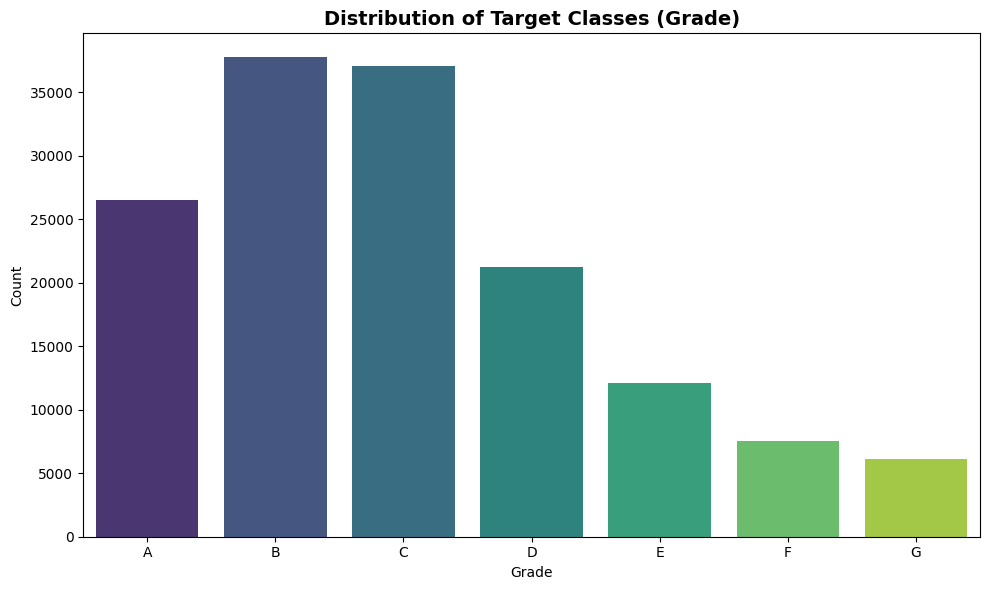

In [4]:
# Target distribution
class_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Target Classes (Grade)", fontsize=14, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# PCA visualization
from sklearn.decomposition import PCA

X_numeric = df.select_dtypes(include=[np.number]).fillna(0)
X_pca = PCA(n_components=2).fit_transform(X_numeric)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grade"], palette="viridis", alpha=0.3, s=10)
plt.title("PCA of Numeric Features (2D)")
plt.tight_layout()
plt.show()

## 2. ML Models (Full-Data Cross-Validation)

The ML pipeline uses **all** the data with `GridSearchCV` (3-fold stratified CV).
Preprocessing is embedded inside the pipeline, so there is no data leakage.

In [5]:
# Prepare ML data (loads, engineers, builds preprocessor)
X_ml, y_ml, col_lists, preprocessor, global_scaler, le_ml = prepare_ml_data(TRAIN_CSV)
print(f"\nML data ready: X={X_ml.shape}, y={y_ml.shape}")

Loaded 148301 rows  (dropped 0 duplicates)
Dropped 0 cols with >80% missing
Dropped 11 collinear cols


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:211: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:223: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Feature engineering done  ->  159 features
  normal_dist      : 49
  safe_log_cols    : 81
  negative_cols    : 3
  ordinal_cols     : 6
  one_hot_cols     : 14
  target_encode_cols: 2

ML data ready: X=(148301, 159), y=(148301,)


### 2.1 Random Forest

In [ ]:
# Hyperparameters — edit here
rf_param_grid = {
    "classifier__n_estimators": [500],
    "classifier__max_depth": [None],
    "classifier__min_samples_split": [8],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": ["sqrt", 0.3],
}

gs_rf = train_random_forest(X_ml, y_ml, preprocessor, param_grid=rf_param_grid)

In [ ]:
# Save & inspect (separate cell — re-run without retraining)
try:
    save_model(gs_rf.best_estimator_, "rf")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_rf, "Random Forest")

In [ ]:
plot_rf_feature_importances(gs_rf, top_k=20)

### 2.2 KNN

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

knn_param_grid = {
    "pca__n_components": [20, 40, None],
    "scaler__scaler_op": [RobustScaler(), StandardScaler(), MinMaxScaler()],
    "classifier__n_neighbors": [30, 50, 100],
    "classifier__weights": ["distance"],
    "classifier__p": [1, 2],
}

gs_knn = train_knn(X_ml, y_ml, preprocessor, global_scaler, param_grid=knn_param_grid)

In [ ]:
try:
    save_model(gs_knn.best_estimator_, "knn")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_knn, "KNN")

### 2.3 SVM

In [ ]:
svm_param_grid = {
    "scaler__scaler_op": [RobustScaler(), StandardScaler(), MinMaxScaler()],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__kernel": ["linear", "poly", "rbf"],
    "classifier__gamma": ["scale"],
}

gs_svm = train_svm(X_ml, y_ml, preprocessor, global_scaler, param_grid=svm_param_grid)

In [ ]:
try:
    save_model(gs_svm.best_estimator_, "svm")
except Exception as e:
    print(f"Error saving model: {e}")
    
print_grid_results(gs_svm, "SVM")

## 3. Deep Learning Models (80/10/10 Split)

DL uses an explicit train/val/test split. Preprocessing is fit on train only.

In [ ]:
# Prepare DL data
#TODO: check if data are splitted in a balanced way
dl_data = prepare_dl_data(TRAIN_CSV, val_size=0.10, test_size=0.10)

print(f"\nDL data shapes:")
print(f"  X_train: {dl_data['X_train'].shape}")
print(f"  X_val  : {dl_data['X_val'].shape}")
print(f"  X_test : {dl_data['X_test'].shape}")
print(f"  Num cols: {dl_data['num_num_cols']}, Cat cols: {dl_data['num_cat_cols']}")
print(f"  Classes : {dl_data['num_classes']}")
print(f"  Cat cardinalities: {dl_data['cat_cardinalities']}")
print(f"  Feature names ({len(dl_data['feature_names'])}): {dl_data['feature_names'][:10]}...")

In [ ]:
# Class weights (shared across all DL models)
class_weights_array = get_class_weights(dl_data["y_train"])
class_weights_dict = get_class_weights_dict(dl_data["y_train"])
class_names = [f"Grade {c}" for c in dl_data["label_encoder"].classes_]
feature_names = dl_data["feature_names"]

print(f"Class weights: {dict(enumerate(class_weights_array))}")
print(f"Class names: {class_names}")
print(f"Feature names: {len(feature_names)} total")

In [ ]:
print(f"Numerical: {dl_data['num_num_cols']}")
print(f"Categorical: {dl_data['num_cat_cols']}")
print(f"Cat names: {dl_data['categorical_cols']}")

In [ ]:
for name, y in [("Train", dl_data["y_train"]),
                ("Val",   dl_data["y_val"]),
                ("Test",  dl_data["y_test"])]:
    unique, counts = np.unique(y, return_counts=True)
    pcts = counts / counts.sum() * 100
    print(f"{name:5s}: {dict(zip(unique, [f'{p:.1f}%' for p in pcts]))}")

### 3.1 Feed-Forward Neural Network (FFNN)

In [ ]:
# ── FFNN Hyperparameters (edit here) ──
FFNN_HP = dict(
    # Architecture
    hidden_units=[256, 128, 64],
    dropout_rates=[0.3, 0.05],
    # Training
    num_epochs=300,
    batch_size=256,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=25,
    scheduler_patience=5,
    scheduler_factor=0.3,
)

In [ ]:
# Build datasets and loaders
train_ds = LoanDataset(dl_data["X_train"], dl_data["y_train"])
val_ds   = LoanDataset(dl_data["X_val"],   dl_data["y_val"])
test_ds  = LoanDataset(dl_data["X_test"],  dl_data["y_test"])

train_loader, val_loader, test_loader = create_loaders(
    train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
)

print(f"Input dim: {train_ds.num_features}, Output dim: {train_ds.num_classes}")

In [ ]:
# Build & train FFNN
fix_random(SEED)

ffnn_model = LoanClassifierFFNN(
    input_dim=train_ds.num_features,
    output_dim=train_ds.num_classes,
    hidden_units=FFNN_HP["hidden_units"],
    dropout_rates=FFNN_HP["dropout_rates"],
).to(DEVICE)

print(ffnn_model)
print(f"Parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")

In [ ]:
ffnn_model, t_losses, v_losses = train_model(
    model=ffnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=FFNN_HP["num_epochs"],
    patience=FFNN_HP["patience"],
    learning_rate=FFNN_HP["learning_rate"],
    weight_decay=FFNN_HP["weight_decay"],
    scheduler_patience=FFNN_HP["scheduler_patience"],
    scheduler_factor=FFNN_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_ffnn.pkl",
    model_type="standard",
)

plot_losses(t_losses, v_losses, title="FFNN: Training vs Validation Loss")

In [ ]:
# Evaluate FFNN
ffnn_results = evaluate_model(
    ffnn_model, test_loader, DEVICE,
    class_names=class_names, model_type="standard", set_name="FFNN Test"
)
plot_confusion_matrix(ffnn_results["y_true"], ffnn_results["y_pred"],
                      class_names=class_names, title="FFNN Confusion Matrix")

### 3.2 TabNet

In [ ]:
# ── TabNet Hyperparameters (edit here) ──
TABNET_HP = dict(
    # Architecture
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    cat_emb_dim=8,
    # Optimization
    lr=0.02,
    scheduler_step_size=50,
    scheduler_gamma=0.9,
    # Regularization
    lambda_sparse=1e-4,
    momentum=0.3,
    mask_type="sparsemax",
    # Training
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)

In [ ]:
# Build TabNet
tabnet_model = build_tabnet_classifier(
    cat_indices=dl_data["cat_indices"],
    cat_cardinalities=dl_data["cat_cardinalities"],
    device=DEVICE,
    seed=SEED,
    n_d=TABNET_HP["n_d"],
    n_a=TABNET_HP["n_a"],
    n_steps=TABNET_HP["n_steps"],
    gamma=TABNET_HP["gamma"],
    n_independent=TABNET_HP["n_independent"],
    n_shared=TABNET_HP["n_shared"],
    cat_emb_dim=TABNET_HP["cat_emb_dim"],
    lr=TABNET_HP["lr"],
    scheduler_step_size=TABNET_HP["scheduler_step_size"],
    scheduler_gamma=TABNET_HP["scheduler_gamma"],
    lambda_sparse=TABNET_HP["lambda_sparse"],
    momentum=TABNET_HP["momentum"],
    mask_type=TABNET_HP["mask_type"],
)

In [ ]:
# Train TabNet
tabnet_model = train_tabnet(
    model=tabnet_model,
    X_train=dl_data["X_train"],
    y_train=dl_data["y_train"],
    X_val=dl_data["X_val"],
    y_val=dl_data["y_val"],
    max_epochs=TABNET_HP["max_epochs"],
    patience=TABNET_HP["patience"],
    batch_size=TABNET_HP["batch_size"],
    virtual_batch_size=TABNET_HP["virtual_batch_size"],
    class_weights=class_weights_dict,
)

In [ ]:
# Evaluate TabNet
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

y_pred_tabnet = tabnet_model.predict(dl_data["X_test"].astype(np.float32))
y_test = dl_data["y_test"]

print(f"\n{'='*50}")
print(f"  TabNet Test Set Evaluation")
print(f"{'='*50}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  F1 (weighted)     : {f1_score(y_test, y_pred_tabnet, average='weighted'):.4f}")
print(f"  F1 (macro)        : {f1_score(y_test, y_pred_tabnet, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_tabnet, target_names=class_names))

plot_confusion_matrix(y_test, y_pred_tabnet, class_names=class_names, title="TabNet Confusion Matrix")

In [ ]:
# TabNet feature importances
# tabnet_importances = tabnet_model.feature_importances_
# top_k = 20
# top_indices = np.argsort(tabnet_importances)[-top_k:]

# plt.figure(figsize=(10, 6))
# plt.barh(range(top_k), tabnet_importances[top_indices])
# plt.yticks(range(top_k), [f"Feature {i}" for i in top_indices])
# plt.title(f"TabNet — Top {top_k} Feature Importances")
# plt.xlabel("Importance")
# plt.tight_layout()
# plt.show()

plot_feature_importances(
    importances=tabnet_model.feature_importances_,
    feature_names=feature_names,
    top_k=20,
    title="TabNet — Feature Importances",
)

In [ ]:
tabnet_save_path = os.path.join(MODEL_DIR, "best_tabnet")
tabnet_model.save_model(tabnet_save_path)
print(f"TabNet model saved to {tabnet_save_path}")

In [ ]:
save_model(tabnet_model, "best_tabnet")

### 3.3 Tab Transformer

In [ ]:
# ── TabTransformer Hyperparameters (edit here) ──
TABT_HP = dict(
    # Architecture
    dim=32,
    depth=3,
    heads=4,
    attn_dropout=0.4,
    ff_dropout=0.4,
    mlp_hidden_mults=(2, 1),
    # Training
    num_epochs=100,
    batch_size=1024,
    learning_rate=3e-4,
    weight_decay=0.05,
    patience=20,
    #scheduler_patience=7,
    #scheduler_factor=0.5,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=5,
)

In [ ]:
# Build datasets (TabularDataset splits num/cat)
n_num = dl_data["num_num_cols"]

train_ds_tt = TabularDataset(dl_data["X_train"], dl_data["y_train"], n_num)
val_ds_tt   = TabularDataset(dl_data["X_val"],   dl_data["y_val"],   n_num)
test_ds_tt  = TabularDataset(dl_data["X_test"],  dl_data["y_test"],  n_num)

train_loader_tt, val_loader_tt, test_loader_tt = create_loaders(
    train_ds_tt, val_ds_tt, test_ds_tt, batch_size=TABT_HP["batch_size"]
)

print(f"Numeric: {train_ds_tt.n_num}, Categorical: {train_ds_tt.n_cat}")

In [ ]:
# Build & train TabTransformer
fix_random(SEED)

tab_transformer = build_tab_transformer(
    cat_cardinalities=tuple(dl_data["cat_cardinalities"]),
    num_continuous=dl_data["num_num_cols"],
    cont_mean_std=dl_data["cont_mean_std"],
    num_classes=dl_data["num_classes"],
    dim=TABT_HP["dim"],
    depth=TABT_HP["depth"],
    heads=TABT_HP["heads"],
    attn_dropout=TABT_HP["attn_dropout"],
    ff_dropout=TABT_HP["ff_dropout"],
    mlp_hidden_mults=TABT_HP["mlp_hidden_mults"],
    device=DEVICE,
)

print(tab_transformer)
print(f"Parameters: {sum(p.numel() for p in tab_transformer.parameters()):,}")

In [ ]:
tab_transformer, t_losses_tt, v_losses_tt = train_model(
    model=tab_transformer,
    train_loader=train_loader_tt,
    val_loader=val_loader_tt,
    num_epochs=TABT_HP["num_epochs"],
    patience=TABT_HP["patience"],
    learning_rate=TABT_HP["learning_rate"],
    weight_decay=TABT_HP["weight_decay"],
    #scheduler_patience=TABT_HP["scheduler_patience"],
    #scheduler_factor=TABT_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_tab_transformer.pkl",
    model_type="tab_transformer",
    max_grad_norm=TABT_HP.get("max_grad_norm"),
    use_cosine_scheduler=TABT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=TABT_HP.get("warmup_epochs", 0)
)

plot_losses(t_losses_tt, v_losses_tt, title="TabTransformer: Training vs Validation Loss")

In [ ]:
# Evaluate TabTransformer
tt_results = evaluate_model(
    tab_transformer, test_loader_tt, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="TabTransformer Test"
)
plot_confusion_matrix(tt_results["y_true"], tt_results["y_pred"],
                      class_names=class_names, title="TabTransformer Confusion Matrix")

### 3.4 FT-Transformer (attention over ALL features)

Unlike TabTransformer (which only applies attention to categorical features),
FTTransformer tokenizes **all** features — numerical and categorical — into
embeddings, then runs self-attention over the full set. This is better suited
for datasets with many numerical features (105 numerical vs 13 categorical here).

In [ ]:
# ── FTTransformer Hyperparameters (edit here) ──
FT_HP = dict(
    # Architecture
    dim=64,
    depth=4,
    heads=8,
    attn_dropout=0.2,
    ff_dropout=0.2,
    # Training
    num_epochs=100,
    batch_size=512,
    learning_rate=1e-4,
    weight_decay=1e-3,
    patience=25,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=5,
)

In [ ]:
# Build datasets (same TabularDataset as TabTransformer)
n_num = dl_data["num_num_cols"]

train_ds_ft = TabularDataset(dl_data["X_train"], dl_data["y_train"], n_num)
val_ds_ft   = TabularDataset(dl_data["X_val"],   dl_data["y_val"],   n_num)
test_ds_ft  = TabularDataset(dl_data["X_test"],  dl_data["y_test"],  n_num)

train_loader_ft, val_loader_ft, test_loader_ft = create_loaders(
    train_ds_ft, val_ds_ft, test_ds_ft, batch_size=FT_HP["batch_size"]
)

print(f"Numeric: {train_ds_ft.n_num}, Categorical: {train_ds_ft.n_cat}")

In [ ]:
# Build FTTransformer
fix_random(SEED)

ft_transformer = build_ft_transformer(
    cat_cardinalities=tuple(dl_data["cat_cardinalities"]),
    num_continuous=dl_data["num_num_cols"],
    num_classes=dl_data["num_classes"],
    dim=FT_HP["dim"],
    depth=FT_HP["depth"],
    heads=FT_HP["heads"],
    attn_dropout=FT_HP["attn_dropout"],
    ff_dropout=FT_HP["ff_dropout"],
    device=DEVICE,
)

print(ft_transformer)
print(f"Parameters: {sum(p.numel() for p in ft_transformer.parameters()):,}")

In [ ]:
# Train FTTransformer
ft_transformer, t_losses_ft, v_losses_ft = train_model(
    model=ft_transformer,
    train_loader=train_loader_ft,
    val_loader=val_loader_ft,
    num_epochs=FT_HP["num_epochs"],
    patience=FT_HP["patience"],
    learning_rate=FT_HP["learning_rate"],
    weight_decay=FT_HP["weight_decay"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_ft_transformer.pkl",
    model_type="tab_transformer",  # same forward interface: model(x_cat, x_num)
    max_grad_norm=FT_HP.get("max_grad_norm"),
    use_cosine_scheduler=FT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=FT_HP.get("warmup_epochs", 0),
)

plot_losses(t_losses_ft, v_losses_ft, title="FTTransformer: Training vs Validation Loss")

In [ ]:
# Evaluate FTTransformer
ft_results = evaluate_model(
    ft_transformer, test_loader_ft, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="FTTransformer Test"
)
plot_confusion_matrix(ft_results["y_true"], ft_results["y_pred"],
                      class_names=class_names, title="FTTransformer Confusion Matrix")

## 4. Results Comparison

In [ ]:
print(f"\n{'='*60}")
print(f"  RESULTS COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Bal Acc':>10} {'F1 macro':>10}")
print(f"{'-'*60}")

# ML models (CV results)
for name, gs in [("Random Forest", gs_rf), ("KNN", gs_knn), ("SVM", gs_svm)]:
    idx = gs.best_index_
    acc = gs.cv_results_["mean_test_accuracy"][idx]
    bal = gs.cv_results_["mean_test_balanced_accuracy"][idx]
    f1m = gs.cv_results_["mean_test_f1_macro"][idx]
    print(f"{name:<20} {acc:>10.4f} {bal:>10.4f} {f1m:>10.4f}  (CV)")

# DL models (test set)
print(f"{'FFNN':<20} {ffnn_results['accuracy']:>10.4f} {ffnn_results['balanced_accuracy']:>10.4f} {ffnn_results['f1_macro']:>10.4f}  (test)")

tabnet_acc = accuracy_score(y_test, y_pred_tabnet)
tabnet_bal = balanced_accuracy_score(y_test, y_pred_tabnet)
tabnet_f1m = f1_score(y_test, y_pred_tabnet, average="macro")
print(f"{'TabNet':<20} {tabnet_acc:>10.4f} {tabnet_bal:>10.4f} {tabnet_f1m:>10.4f}  (test)")

print(f"{'TabTransformer':<20} {tt_results['accuracy']:>10.4f} {tt_results['balanced_accuracy']:>10.4f} {tt_results['f1_macro']:>10.4f}  (test)")